# EEG_09 — Domain Adversarial GAT per Imagined Speech Decoding

## Motivazione

EEG_08 (ChebGCN statico) ha mostrato performance a chance (val_bacc ≈ 25%) in setting
subject-independent. Causa identificata dall'analisi esplorativa (EEG_00/01):

> **ε²(soggetto) = 0.85** — l'85% della varianza EEG è spiegata dall'identità del soggetto  
> **ε²(parola)   = 0.03** — solo il 3% è spiegato dal contenuto semantico della parola

Un modello senza domain adaptation, anche con architettura di grafo sofisticata, non riesce
a estrarre il segnale semantico in presenza di questa dominanza inter-soggetto.

---

## Soluzione: Domain Adversarial Graph Attention Network

### Paper di riferimento

**1. Graph Attention Networks (GAT)**  
Veličković et al., ICLR 2018 — arXiv:1710.10903  
Multi-head attention sugli archi: la rete impara il peso di ogni connessione in funzione
delle feature dei nodi. Vantaggio rispetto a ChebConv (EEG_08): le connessioni rilevanti
vengono amplificate automaticamente, senza pesi fissi imposti dalla struttura del grafo.

**2. Domain-Adversarial Neural Networks (DANN)**  
Ganin et al., JMLR 2016  
Gradient Reversal Layer (GRL): durante il forward propaga l'input invariato; durante il
backward inverte il gradiente (moltiplicazione per −α). Il feature extractor viene così
incentivato a produrre embedding che il discriminatore di dominio non riesce a distinguere.

**3. DAGAM — Domain Adversarial Graph Attention Model**  
Xu et al., Journal of Neural Engineering, 2023 — arXiv:2202.12948  
Prima applicazione di GAT + adversarial training per EEG cross-subject.  
Task: emotion recognition. Risultati: SEED 92.59%, SEED-IV 80.74% (vs baseline ~70%).  
*Adattiamo l'architettura al task di imagined speech decoding end-to-end.*

### Contributo originale di questo notebook
- Applicazione al task imagined speech (non emotion recognition come in DAGAM)
- Temporal Encoder 1D CNN per-nodo: invariato da EEG_08 (trial interi ~1.5s)
- Grafo PCC k-NN k=6: invariato da EEG_08 (ispirato a Lun et al. 2022)

---

## Architettura

```
Input EEG: (batch × 59 nodi, 384 campioni)
          │
          ▼
 ┌────────────────────────┐
 │    Temporal Encoder    │  1D CNN per-nodo (pesi condivisi)
 │  Conv1d×2 + Linear     │  384 campioni → NODE_EMB_DIM = 64
 └──────────┬─────────────┘
            │  grafo PCC k-NN (k=6, da Lun et al. 2022)
            ▼
 ┌────────────────────────┐
 │   GATConv × 2 (o ×3)  │  Multi-head attention (GAT_HEADS=8)
 │   64 → 8×64 → 64      │  Veličković et al. 2018
 └──────────┬─────────────┘
            │
            ▼  global_mean_pool
 ┌────────────────────────┐
 │   Shared Embedding     │  (batch, GAT_HIDDEN=64)
 └──────┬─────────────────┘
        │                        │
        ▼                        ▼ ── GRL(α) ──   ← solo modelli _ADV
 Task Classifier           Subject Discriminator
 (N_CLASSES=4)             (N_SUBJ_TRAIN=50)
 L_task                    L_subj (grad reversed)
        │
 L_tot = L_task + λ_adv · L_subj
 (il GRL fa sì che il feature extractor massimizzi L_subj
  mentre il discriminatore la minimizza → embedding soggetto-invarianti)
```

## Modelli

| Modello      | GATConv  | Adversarial | Note                              |
|--------------|----------|-------------|-----------------------------------|
| `GAT_2L`     | 2 layer  | ✗           | Baseline GAT, senza domain adapt. |
| `GAT_2L_ADV` | 2 layer  | ✓           | DAGAM-style, λ=LAMBDA_ADV         |
| `GAT_3L_ADV` | 3 layer  | ✓           | Versione più profonda              |


In [2]:
# ═══════════════════════════════════════════════════════════
#  TOGGLE CLASSI TARGET — modifica qui per cambiare schema
# ═══════════════════════════════════════════════════════════
USE_CLUSTERS   = True        # False → 110 parole originali
CLUSTER_SCHEME = "concr4"   # "ward4" | "ward5" | "sem5" | "pos4" | "concr4"
#                              (ignorato se USE_CLUSTERS = False)
# ───────────────────────────────────────────────────────────
K_GRAPH       = 6            # k-NN sul PCC (invariato da EEG_08)
GAT_HEADS     = 8            # teste di attenzione GATConv
GAT_HIDDEN    = 64           # dimensione embedding dopo GATConv
NODE_EMB_DIM  = 64           # output Temporal Encoder
LAMBDA_ADV    = 0.5          # peso del termine adversariale nella loss
#                              (0 = nessuna adaptation, 1 = forte penalità soggetto)
#                              v1: 0.1 → early stop prima che alpha faccia effetto
#                              v2: 0.5 → pressione adversariale più forte
# ═══════════════════════════════════════════════════════════

In [3]:
import os, math
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # fix OpenMP su macOS

import json
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.tensorboard import SummaryWriter
from torch.autograd import Function
from tqdm.auto import tqdm
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

# PyTorch Geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GATConv, global_mean_pool

# Device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
print("Python:", __import__('sys').version.split()[0])
print("torch:", torch.__version__)
import torch_geometric; print("torch_geometric:", torch_geometric.__version__)

device: cuda
Python: 3.11.15
torch: 2.10.0+cu128
torch_geometric: 2.7.0


In [4]:
# ============================================================
# CONFIGURAZIONE
# ============================================================

project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)

META_CSV  = project_root / "data" / "interim" / "eeg_metadata.csv"
ELOC_PATH = project_root / "src" / "io" / "ebneuro.locs"
interim_dir = project_root / "data" / "interim"

# Parametri EEG
N_CHANS  = 59    # canali dopo rimozione A1, A2
N_TIMES  = 384   # campioni a 256 Hz (~1.5s)
SFREQ    = 256

# Training
BATCH_SIZE      = 32
MAX_EPOCHS      = 100
PATIENCE        = 15   # modelli standard (GAT_2L)
PATIENCE_ADV    = 40   # modelli adversariali (_ADV): serve più tempo per alpha↑
#                       v1: 15 → early stop a epoch ~19, alpha ancora basso
#                       v2: 40 → dà al GRL tempo di agire (alpha>0.7 da epoch ~35)
LR           = 1e-3
WEIGHT_DECAY = 1e-4

# Split subject-independent (identico a EEG_05 / EEG_08)
SUBJ_TRAIN     = list(range(50))
SUBJ_VAL       = list(range(50, 60))
SUBJ_TEST      = list(range(60, 74))
N_SUBJ_TRAIN   = len(SUBJ_TRAIN)   # 50 — dimensione del discriminatore soggetto

# Resume
RESUME = True

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("Config OK")
print(f"project_root: {project_root}")
print(f"N_SUBJ_TRAIN (discriminatore): {N_SUBJ_TRAIN}")

Config OK
project_root: /home/daniele_u/miralis-hypergraph-imagined-speech
N_SUBJ_TRAIN (discriminatore): 50


In [5]:
# ============================================================
# METADATA + CLUSTER MAPPING
# ============================================================

import sys
sys.path.insert(0, str(project_root / "scripts"))
from utils import load_label_scheme

meta = pd.read_csv(META_CSV)

# Filtro righe corrotte (epoche fuori range note)
_initial_len = len(meta)
meta = meta[~(
    (meta["path_h5"].str.contains("08_05.h5") & (meta["epoch_idx"] >= 110)) |
    (meta["path_h5"].str.contains("46_01.h5") & (meta["epoch_idx"] >= 110)) |
    (meta["path_h5"].str.contains("46_03.h5") & (meta["epoch_idx"] >= 110)) |
    (meta["path_h5"].str.contains("46_04.h5") & (meta["epoch_idx"] >= 34))
)]
if len(meta) < _initial_len:
    print(f"Rimosse {_initial_len - len(meta)} righe corrotte.")
meta["subject_id"] = meta["subject_id"].astype(str).str.zfill(2)

def read_eloc_names(path):
    names = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 4:
                names.append(parts[3])
    return names[:61]

ch_names_61 = read_eloc_names(ELOC_PATH)
EXCLUDE    = {"A1", "A2"}
keep_idx   = [i for i, n in enumerate(ch_names_61) if n not in EXCLUDE]
keep_names = [ch_names_61[i] for i in keep_idx]
assert len(keep_idx) == N_CHANS, f"Attesi {N_CHANS} canali, trovati {len(keep_idx)}"

_scheme = CLUSTER_SCHEME if USE_CLUSTERS else "raw110"
labelid2cluster, N_CLASSES, cluster_names = load_label_scheme(_scheme, interim_dir)

RESULTS_CSV = project_root / "data" / "interim" / f"eeg09_gat_{N_CLASSES}_results.csv"

print(f"Schema: {'clustering ' + CLUSTER_SCHEME if USE_CLUSTERS else '110 parole'}")
print(f"Classi: {N_CLASSES}  |  Chance level: {100/N_CLASSES:.1f}%")
print(f"Canali: {len(keep_names)} — {keep_names[:5]}...")
print(f"Totale record: {len(meta)}")

Rimosse 9 righe corrotte.
Schema: clustering concr4
Classi: 4  |  Chance level: 25.0%
Canali: 59 — ['AF7', 'AF3', 'Fp1', 'FP2', 'AF4']...
Totale record: 39183


In [6]:
# ============================================================
# GRAFO FUNZIONALE: k-NN sul PCC calcolato sui dati di training
# Invariato da EEG_08 — ispirato a Lun et al. 2022 (GCNs-Net)
# ============================================================

def read_eloc_positions(eloc_path, keep_names):
    """
    Legge posizioni elettrodi dal file .locs (EEGLab format).
    Formato: chan_num  theta(gradi)  radius(0-1)  name
    Proiezione 2D top-down: x = radius*sin(theta_rad), y = radius*cos(theta_rad)
    """
    pos = {}
    with open(eloc_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 4:
                continue
            try:
                theta  = float(parts[1])
                radius = float(parts[2])
                name   = parts[3]
            except ValueError:
                continue
            if name not in keep_names:
                continue
            th = math.radians(theta)
            pos[name] = (radius * math.sin(th), radius * math.cos(th))
    return pos


def compute_pcc_knn_graph(meta_df, keep_idx, keep_names, subj_train_ids,
                          k=6, n_samples=1000, seed=42):
    """
    Grafo k-NN funzionale via |PCC| medio su trial di training.
    Ispirato a: Lun et al. 2022 (GCNs-Net), IEEE TNSRE — arXiv:2006.08924
    """
    rng = np.random.RandomState(seed)
    train_records = meta_df[meta_df["subject_id"].isin(subj_train_ids)][["path_h5", "epoch_idx"]]
    n = min(n_samples, len(train_records))
    sampled = train_records.iloc[rng.choice(len(train_records), n, replace=False)]

    paths_map = defaultdict(list)
    for _, row in sampled.iterrows():
        paths_map[row["path_h5"]].append(int(row["epoch_idx"]))

    buf = []
    print(f"Calcolo PCC su {n} trial da {len(paths_map)} file H5...")
    for p, epoch_idxs in tqdm(paths_map.items(), desc="PCC H5", leave=False):
        with h5py.File(p, "r") as f:
            for e_idx in epoch_idxs:
                buf.append(f["data"][e_idx][keep_idx, :].astype(np.float32))

    pcc_sum = np.zeros((len(keep_idx), len(keep_idx)), dtype=np.float64)
    for x in buf:
        pcc_sum += np.abs(np.corrcoef(x))
    pcc_matrix = (pcc_sum / len(buf)).astype(np.float32)
    np.fill_diagonal(pcc_matrix, 0.0)

    edges = set()
    for i in range(len(keep_idx)):
        for j in np.argsort(pcc_matrix[i])[::-1][:k]:
            edges.add((i, int(j))); edges.add((int(j), i))

    src, dst = zip(*sorted(edges))
    edge_index = torch.tensor([list(src), list(dst)], dtype=torch.long)
    n_nodes, n_edges = len(keep_idx), edge_index.shape[1]
    print(f"Grafo PCC k-NN (k={k}): {n_nodes} nodi, {n_edges} archi, grado medio {n_edges/n_nodes:.1f}")
    return edge_index, pcc_matrix


train_ids = [str(i).zfill(2) for i in SUBJ_TRAIN]
eloc_pos  = read_eloc_positions(ELOC_PATH, set(keep_names))
edge_index, pcc_matrix = compute_pcc_knn_graph(
    meta, keep_idx, keep_names, train_ids, k=K_GRAPH, n_samples=1000
)
print("Grafo OK — riuso da EEG_08, invariato")

Calcolo PCC su 1000 trial da 240 file H5...


PCC H5:   0%|          | 0/240 [00:00<?, ?it/s]

Grafo PCC k-NN (k=6): 59 nodi, 420 archi, grado medio 7.1
Grafo OK — riuso da EEG_08, invariato


In [7]:
# ============================================================
# DATASET PyG — aggiunto campo `subj` per adversarial training
# ============================================================

class EEGGraphDataset(Dataset):
    """
    Dataset PyG: ogni trial EEG diventa un grafo.
    Rispetto a EEG_08: aggiunto Data.subj = id soggetto (int)
    usato dal discriminatore durante il training adversariale.
    """
    def __init__(self, records, keep_idx, labelid2cluster, edge_index, mean=None, std=None):
        self.records        = records
        self.keep_idx       = keep_idx
        self.labelid2cluster = labelid2cluster
        self.edge_index     = edge_index
        self.mean           = mean
        self.std            = std
        self.file_cache     = {}
        if mean is None:
            self._compute_stats()

    def _compute_stats(self, seed=42):
        rng  = np.random.RandomState(seed)
        n    = min(500, len(self.records))
        idxs = rng.choice(len(self.records), n, replace=False)
        paths_map = defaultdict(list)
        for idx in idxs:
            r = self.records[idx]
            paths_map[r["path_h5"]].append(int(r["epoch_idx"]))
        buf = []
        print(f"Calcolo stats su {n} campioni da {len(paths_map)} file...")
        for path, epoch_idxs in tqdm(paths_map.items(), desc="Stats H5", leave=False):
            with h5py.File(path, "r") as f:
                for e_idx in epoch_idxs:
                    buf.append(f["data"][e_idx][self.keep_idx, :].astype(np.float32))
        buf = np.stack(buf)
        self.mean = torch.tensor(buf.mean(axis=(0,2), keepdims=True).squeeze(0), dtype=torch.float32)
        self.std  = torch.tensor(buf.std(axis=(0,2),  keepdims=True).squeeze(0).clip(1e-6), dtype=torch.float32)
        print(f"Stats OK | mean range: [{self.mean.min():.3f}, {self.mean.max():.3f}]")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r    = self.records[idx]
        path = r["path_h5"]
        if path not in self.file_cache:
            self.file_cache[path] = h5py.File(path, "r")
        x = self.file_cache[path]["data"][int(r["epoch_idx"])][self.keep_idx, :].astype(np.float32)
        x = (torch.tensor(x, dtype=torch.float32) - self.mean) / self.std
        label   = self.labelid2cluster[int(r["label_idx"])]
        subj_id = int(r["subject_id"])
        return Data(
            x          = x,
            edge_index = self.edge_index,
            y          = torch.tensor(label,   dtype=torch.long),
            subj       = torch.tensor(subj_id, dtype=torch.long),
        )

    def __del__(self):
        for f in self.file_cache.values():
            try: f.close()
            except: pass


def make_graph_splits(meta_df, labelid2cluster, subj_train, subj_val, subj_test, edge_index):
    def to_records(df_sub):
        return df_sub[["path_h5", "epoch_idx", "label_idx", "subject_id"]].to_dict("records")

    train_ids = [str(i).zfill(2) for i in subj_train]
    val_ids   = [str(i).zfill(2) for i in subj_val]
    test_ids  = [str(i).zfill(2) for i in subj_test]

    r_tr = to_records(meta_df[meta_df["subject_id"].isin(train_ids)])
    r_va = to_records(meta_df[meta_df["subject_id"].isin(val_ids)])
    r_te = to_records(meta_df[meta_df["subject_id"].isin(test_ids)])

    print(f"Split: train={len(r_tr)} | val={len(r_va)} | test={len(r_te)}")

    ds_tr = EEGGraphDataset(r_tr, keep_idx, labelid2cluster, edge_index)
    ds_va = EEGGraphDataset(r_va, keep_idx, labelid2cluster, edge_index, mean=ds_tr.mean, std=ds_tr.std)
    ds_te = EEGGraphDataset(r_te, keep_idx, labelid2cluster, edge_index, mean=ds_tr.mean, std=ds_tr.std)
    return ds_tr, ds_va, ds_te

print("EEGGraphDataset OK")

EEGGraphDataset OK


In [8]:
# ============================================================
# MODELLI — GAT + Domain Adversarial (DAGAM-style)
# GAT: Veličković et al. 2018 — arXiv:1710.10903
# Adversarial: Ganin et al. 2016 (DANN) + Xu et al. 2023 (DAGAM)
# Temporal Encoder: contributo originale (invariato da EEG_08)
# ============================================================

# ── Gradient Reversal Layer (Ganin et al. 2016) ──────────────
class GradReverse(Function):
    """
    Forward: passa x invariato.
    Backward: inverte il gradiente moltiplicando per -alpha.
    Effetto: il feature extractor massimizza la loss del discriminatore
             (rende le feature soggetto-invarianti).
    """
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None

def grad_reverse(x, alpha=1.0):
    return GradReverse.apply(x, alpha)


# ── Temporal Encoder (invariato da EEG_08) ───────────────────
class TemporalEncoder(nn.Module):
    """
    1D CNN per-nodo (pesi condivisi tra tutti gli elettrodi).
    Input:  (N_nodes_total, N_TIMES)
    Output: (N_nodes_total, out_dim)
    """
    def __init__(self, n_times=N_TIMES, out_dim=NODE_EMB_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=25, stride=2, padding=12),
            nn.BatchNorm1d(32), nn.ELU(),
            nn.Conv1d(32, 64, kernel_size=10, stride=2, padding=5),
            nn.BatchNorm1d(64), nn.ELU(),
            nn.AdaptiveAvgPool1d(4),
            nn.Flatten(),
            nn.Linear(64 * 4, out_dim),
            nn.ELU(),
        )
    def forward(self, x):
        return self.net(x.unsqueeze(1))   # (N, 1, T) → (N, out_dim)


# ── GAT_2L — Baseline senza domain adaptation ────────────────
class TemporalGAT(nn.Module):
    """
    Temporal Encoder + 2 GATConv senza adversarial training.
    Baseline: dimostra se il meccanismo di attenzione del grafo
    da solo aiuta rispetto a ChebConv (EEG_08).
    """
    def __init__(self, n_classes=N_CLASSES, n_times=N_TIMES,
                 node_emb_dim=NODE_EMB_DIM, gat_heads=GAT_HEADS,
                 gat_hidden=GAT_HIDDEN, dropout=0.5):
        super().__init__()
        self.temporal_enc = TemporalEncoder(n_times, node_emb_dim)
        self.conv1 = GATConv(node_emb_dim, gat_hidden, heads=gat_heads,
                             dropout=dropout, concat=True)
        self.bn1   = nn.BatchNorm1d(gat_hidden * gat_heads)
        self.conv2 = GATConv(gat_hidden * gat_heads, gat_hidden,
                             heads=1, dropout=dropout, concat=False)
        self.bn2   = nn.BatchNorm1d(gat_hidden)
        self.drop  = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(gat_hidden, gat_hidden // 2), nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(gat_hidden // 2, n_classes),
        )

    def forward(self, data):
        x, ei, batch = data.x, data.edge_index, data.batch
        x  = self.temporal_enc(x)
        x  = F.elu(self.bn1(self.conv1(x, ei))); x = self.drop(x)
        x  = F.elu(self.bn2(self.conv2(x, ei)))
        x  = global_mean_pool(x, batch)
        return self.classifier(x)


# ── GAT_ADV — Base con domain adversarial (DAGAM-style) ──────
class TemporalGATAdv(nn.Module):
    """
    GAT + Gradient Reversal Layer + Subject Discriminator.
    Architettura ispirata a DAGAM (Xu et al. 2023, arXiv:2202.12948).
    
    forward(data, alpha) → (task_logits, subj_logits)
      alpha: intensità del gradient reversal (0→1 con schedule DANN)
    """
    def __init__(self, n_classes=N_CLASSES, n_subjects=N_SUBJ_TRAIN,
                 n_times=N_TIMES, node_emb_dim=NODE_EMB_DIM,
                 gat_heads=GAT_HEADS, gat_hidden=GAT_HIDDEN, dropout=0.5):
        super().__init__()
        self.temporal_enc = TemporalEncoder(n_times, node_emb_dim)
        self.conv1 = GATConv(node_emb_dim, gat_hidden, heads=gat_heads,
                             dropout=dropout, concat=True)
        self.bn1   = nn.BatchNorm1d(gat_hidden * gat_heads)
        self.conv2 = GATConv(gat_hidden * gat_heads, gat_hidden,
                             heads=1, dropout=dropout, concat=False)
        self.bn2   = nn.BatchNorm1d(gat_hidden)
        self.drop  = nn.Dropout(dropout)
        # Task classifier
        self.task_cls = nn.Sequential(
            nn.Linear(gat_hidden, gat_hidden // 2), nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(gat_hidden // 2, n_classes),
        )
        # Subject discriminator (dopo GRL)
        self.subj_disc = nn.Sequential(
            nn.Linear(gat_hidden, gat_hidden // 2), nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(gat_hidden // 2, n_subjects),
        )

    def forward(self, data, alpha=1.0):
        x, ei, batch = data.x, data.edge_index, data.batch
        x    = self.temporal_enc(x)
        x    = F.elu(self.bn1(self.conv1(x, ei))); x = self.drop(x)
        x    = F.elu(self.bn2(self.conv2(x, ei)))
        feat = global_mean_pool(x, batch)          # (B, gat_hidden)
        task_logits = self.task_cls(feat)
        subj_logits = self.subj_disc(grad_reverse(feat, alpha))
        return task_logits, subj_logits


# ── GAT_3L_ADV — Versione più profonda con adversarial ───────
class TemporalGATAdv3L(nn.Module):
    """
    Come TemporalGATAdv ma con 3 layer GATConv.
    """
    def __init__(self, n_classes=N_CLASSES, n_subjects=N_SUBJ_TRAIN,
                 n_times=N_TIMES, node_emb_dim=NODE_EMB_DIM,
                 gat_heads=GAT_HEADS, gat_hidden=GAT_HIDDEN, dropout=0.5):
        super().__init__()
        self.temporal_enc = TemporalEncoder(n_times, node_emb_dim)
        self.conv1 = GATConv(node_emb_dim, gat_hidden, heads=gat_heads,
                             dropout=dropout, concat=True)
        self.bn1   = nn.BatchNorm1d(gat_hidden * gat_heads)
        self.conv2 = GATConv(gat_hidden * gat_heads, gat_hidden, heads=gat_heads,
                             dropout=dropout, concat=True)
        self.bn2   = nn.BatchNorm1d(gat_hidden * gat_heads)
        self.conv3 = GATConv(gat_hidden * gat_heads, gat_hidden,
                             heads=1, dropout=dropout, concat=False)
        self.bn3   = nn.BatchNorm1d(gat_hidden)
        self.drop  = nn.Dropout(dropout)
        self.task_cls = nn.Sequential(
            nn.Linear(gat_hidden, gat_hidden // 2), nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(gat_hidden // 2, n_classes),
        )
        self.subj_disc = nn.Sequential(
            nn.Linear(gat_hidden, gat_hidden // 2), nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(gat_hidden // 2, n_subjects),
        )

    def forward(self, data, alpha=1.0):
        x, ei, batch = data.x, data.edge_index, data.batch
        x    = self.temporal_enc(x)
        x    = F.elu(self.bn1(self.conv1(x, ei))); x = self.drop(x)
        x    = F.elu(self.bn2(self.conv2(x, ei))); x = self.drop(x)
        x    = F.elu(self.bn3(self.conv3(x, ei)))
        feat = global_mean_pool(x, batch)
        return self.task_cls(feat), self.subj_disc(grad_reverse(feat, alpha))


# ── Registro modelli ─────────────────────────────────────────
# Ogni entry: costruttore + flag adversarial
GAT_MODELS = {
    "GAT_2L":     {"cls": TemporalGAT,       "adversarial": False},
    "GAT_2L_ADV": {"cls": TemporalGATAdv,    "adversarial": True},
    "GAT_3L_ADV": {"cls": TemporalGATAdv3L,  "adversarial": True},
}

# Conta parametri di ogni modello
for name, cfg in GAT_MODELS.items():
    m = cfg["cls"]()
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{name:15s} {n:>8,} parametri  adversarial={cfg['adversarial']}")

GAT_2L           108,644 parametri  adversarial=False
GAT_2L_ADV       112,374 parametri  adversarial=True
GAT_3L_ADV       377,078 parametri  adversarial=True


In [9]:
# ============================================================
# TRAINING + VALUTAZIONE
# Due funzioni: standard e adversariale
# Schedule alpha: DANN (Ganin et al. 2016) — da 0 a 1 in modo sigmoide
# ============================================================

def _dann_alpha(epoch, total_epochs):
    """Schedule DANN: alpha cresce da ~0 a ~1 durante il training."""
    p = epoch / max(total_epochs, 1)
    return 2.0 / (1.0 + math.exp(-10.0 * p)) - 1.0


def train_gat(model, ds_train, ds_val, save_path, tb_dir,
              n_epochs=MAX_EPOCHS, patience=PATIENCE,
              lr=LR, weight_decay=WEIGHT_DECAY, batch_size=BATCH_SIZE,
              class_weights=None):
    """Training standard (senza adversarial) — per GAT_2L."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    writer    = SummaryWriter(log_dir=str(tb_dir))

    loader_tr = PyGDataLoader(ds_train, batch_size=batch_size, shuffle=True)
    loader_va = PyGDataLoader(ds_val,   batch_size=batch_size, shuffle=False)

    best_val_bacc, patience_cnt = -1.0, 0
    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    history    = defaultdict(list)

    for epoch in range(n_epochs):
        model.train()
        loss_sum, correct, n_tot = 0.0, 0, 0
        for data in tqdm(loader_tr, desc=f"Epoch {epoch+1}/{n_epochs}", leave=False):
            data = data.to(device)
            optimizer.zero_grad()
            logits = model(data)
            loss   = criterion(logits, data.y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            loss_sum += loss.item() * len(data.y)
            correct  += (logits.argmax(1) == data.y).sum().item()
            n_tot    += len(data.y)
        scheduler.step()

        model.eval()
        ys_v, ps_v = [], []
        with torch.no_grad():
            for data in loader_va:
                data = data.to(device)
                ps_v.extend(model(data).argmax(1).cpu().tolist())
                ys_v.extend(data.y.cpu().tolist())

        val_acc  = accuracy_score(ys_v, ps_v)
        val_bacc = balanced_accuracy_score(ys_v, ps_v)
        tr_acc   = correct / n_tot if n_tot > 0 else 0.0
        tr_loss  = loss_sum / n_tot if n_tot > 0 else 0.0

        history["val_acc"].append(val_acc); history["val_bacc"].append(val_bacc)
        history["train_acc"].append(tr_acc); history["train_loss"].append(tr_loss)
        writer.add_scalar("val/acc",    val_acc,  epoch)
        writer.add_scalar("val/bacc",   val_bacc, epoch)
        writer.add_scalar("train/acc",  tr_acc,   epoch)
        writer.add_scalar("train/loss", tr_loss,  epoch)

        if val_bacc > best_val_bacc:
            best_val_bacc = val_bacc
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt  = 0
            save_path.parent.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), save_path)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f"    Early stop @ epoch {epoch+1} (best val_bacc={best_val_bacc:.3f})")
                break

    writer.close()
    model.load_state_dict(best_state)
    return model, dict(history), epoch + 1


def train_gat_adv(model, ds_train, ds_val, save_path, tb_dir,
                  lambda_adv=LAMBDA_ADV,
                  n_epochs=MAX_EPOCHS, patience=PATIENCE,
                  lr=LR, weight_decay=WEIGHT_DECAY, batch_size=BATCH_SIZE,
                  class_weights=None):
    """
    Training adversariale (DAGAM-style).
    Loss = L_task(parola) + lambda_adv * L_subj(soggetto, con GRL)
    L_subj viene minimizzata dal discriminatore ma massimizzata
    dal feature extractor grazie al GRL.
    alpha cresce da 0 a 1 con schedule DANN.
    """
    model = model.to(device)
    optimizer    = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler    = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    task_crit    = nn.CrossEntropyLoss(weight=class_weights)
    subj_crit    = nn.CrossEntropyLoss()
    writer       = SummaryWriter(log_dir=str(tb_dir))

    loader_tr = PyGDataLoader(ds_train, batch_size=batch_size, shuffle=True)
    loader_va = PyGDataLoader(ds_val,   batch_size=batch_size, shuffle=False)

    best_val_bacc, patience_cnt = -1.0, 0
    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    history    = defaultdict(list)

    for epoch in range(n_epochs):
        alpha = _dann_alpha(epoch, n_epochs)   # schedule DANN
        model.train()
        loss_sum, correct, n_tot = 0.0, 0, 0

        for data in tqdm(loader_tr, desc=f"Epoch {epoch+1}/{n_epochs} α={alpha:.2f}", leave=False):
            data = data.to(device)
            optimizer.zero_grad()
            task_logits, subj_logits = model(data, alpha=alpha)
            task_loss = task_crit(task_logits, data.y)
            subj_loss = subj_crit(subj_logits, data.subj)
            loss      = task_loss + lambda_adv * subj_loss
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            loss_sum += task_loss.item() * len(data.y)
            correct  += (task_logits.argmax(1) == data.y).sum().item()
            n_tot    += len(data.y)
        scheduler.step()

        # Validazione: alpha=0 — solo task (soggetti val non sono nel discriminatore)
        model.eval()
        ys_v, ps_v = [], []
        with torch.no_grad():
            for data in loader_va:
                data = data.to(device)
                tl, _ = model(data, alpha=0.0)
                ps_v.extend(tl.argmax(1).cpu().tolist())
                ys_v.extend(data.y.cpu().tolist())

        val_acc  = accuracy_score(ys_v, ps_v)
        val_bacc = balanced_accuracy_score(ys_v, ps_v)
        tr_acc   = correct / n_tot if n_tot > 0 else 0.0
        tr_loss  = loss_sum / n_tot if n_tot > 0 else 0.0

        history["val_acc"].append(val_acc); history["val_bacc"].append(val_bacc)
        history["train_acc"].append(tr_acc); history["train_loss"].append(tr_loss)
        writer.add_scalar("val/acc",    val_acc,  epoch)
        writer.add_scalar("val/bacc",   val_bacc, epoch)
        writer.add_scalar("train/acc",  tr_acc,   epoch)
        writer.add_scalar("train/loss", tr_loss,  epoch)
        writer.add_scalar("train/alpha", alpha,   epoch)

        if val_bacc > best_val_bacc:
            best_val_bacc = val_bacc
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt  = 0
            save_path.parent.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), save_path)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f"    Early stop @ epoch {epoch+1} (best val_bacc={best_val_bacc:.3f})")
                break

    writer.close()
    model.load_state_dict(best_state)
    return model, dict(history), epoch + 1


def evaluate_gat(model, ds, adversarial=False, batch_size=64):
    """Calcola acc e bacc — gestisce sia modelli standard che adversariali."""
    loader = PyGDataLoader(ds, batch_size=batch_size, shuffle=False)
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            if adversarial:
                logits, _ = model(data, alpha=0.0)
            else:
                logits = model(data)
            ps.extend(logits.argmax(1).cpu().tolist())
            ys.extend(data.y.cpu().tolist())
    return {"acc": accuracy_score(ys, ps), "bacc": balanced_accuracy_score(ys, ps)}

print("Funzioni training OK")

Funzioni training OK


In [10]:
# ============================================================
# CLASS WEIGHTS — anti class-collapse
# Calcolati dopo la creazione dei dataset (serve ds_train)
# ============================================================

# Crea i dataset (necessario per calcolare i class weights)
ds_train, ds_val, ds_test = make_graph_splits(
    meta, labelid2cluster,
    SUBJ_TRAIN, SUBJ_VAL, SUBJ_TEST, edge_index
)

# Class weights inversi alla frequenza di classe (su training set)
all_labels = [labelid2cluster[int(r["label_idx"])] for r in ds_train.records]
counts = torch.bincount(torch.tensor(all_labels), minlength=N_CLASSES).float()
class_weights = (1.0 / counts.clamp(min=1))
class_weights = (class_weights / class_weights.sum() * N_CLASSES).to(device)

print("Class weights (training set):")
for i, (c, w) in enumerate(zip(cluster_names, class_weights.cpu())):
    print(f"  classe {i} ({c}): {int(counts[i])} trial → weight={w:.3f}")

Split: train=26166 | val=5500 | test=7260
Calcolo stats su 500 campioni da 215 file...


Stats H5:   0%|          | 0/215 [00:00<?, ?it/s]

Stats OK | mean range: [-0.077, 0.075]
Class weights (training set):
  classe 0 (0): 4290 trial → weight=1.361
  classe 1 (1): 6412 trial → weight=0.911
  classe 2 (2): 4992 trial → weight=1.170
  classe 3 (3): 10472 trial → weight=0.558


In [11]:
# ============================================================
# SANITY CHECK — forward pass su un mini-batch
# ============================================================

print("=== Sanity check forward pass ===")

records_sample = meta[["path_h5", "epoch_idx", "label_idx", "subject_id"]].iloc[:10].to_dict("records")
ds_sample = EEGGraphDataset(records_sample, keep_idx, labelid2cluster, edge_index)
batch_sample = next(iter(PyGDataLoader(ds_sample, batch_size=4, shuffle=False)))

print(f"Batch x shape:          {batch_sample.x.shape}    # (4×59, 384)")
print(f"Batch edge_index shape: {batch_sample.edge_index.shape}")
print(f"Batch y:                {batch_sample.y}")
print(f"Batch subj:             {batch_sample.subj}")

for name, cfg in GAT_MODELS.items():
    m = cfg["cls"]().to(device)
    m.eval()
    with torch.no_grad():
        b = batch_sample.to(device)
        if cfg["adversarial"]:
            tl, sl = m(b, alpha=0.5)
            print(f"  {name}: task_logits={tl.shape}, subj_logits={sl.shape} ✓")
        else:
            tl = m(b)
            print(f"  {name}: task_logits={tl.shape} ✓")
    m.to("cpu")
print("Sanity check OK")

=== Sanity check forward pass ===
Calcolo stats su 10 campioni da 1 file...


Stats H5:   0%|          | 0/1 [00:00<?, ?it/s]

Stats OK | mean range: [-0.514, 0.471]
Batch x shape:          torch.Size([236, 384])    # (4×59, 384)
Batch edge_index shape: torch.Size([2, 1680])
Batch y:                tensor([3, 2, 1, 0])
Batch subj:             tensor([0, 0, 0, 0])
  GAT_2L: task_logits=torch.Size([4, 4]) ✓
  GAT_2L_ADV: task_logits=torch.Size([4, 4]), subj_logits=torch.Size([4, 50]) ✓
  GAT_3L_ADV: task_logits=torch.Size([4, 4]), subj_logits=torch.Size([4, 50]) ✓
Sanity check OK


In [12]:
# ============================================================
# ESPERIMENTO — GAT Subject-Independent
# ============================================================

chance_level = 1.0 / N_CLASSES

TB_BASE   = project_root / "runs"   / f"eeg09_gat_{N_CLASSES}"
CKPT_BASE = project_root / "models" / f"eeg09_gat_{N_CLASSES}"
CKPT_BASE.mkdir(parents=True, exist_ok=True)

if RESUME and RESULTS_CSV.exists():
    df_existing = pd.read_csv(RESULTS_CSV)
    done_models = set(df_existing["model"].tolist())
    results_gat = df_existing.to_dict("records")
    print(f"Resume: trovati {len(done_models)} modelli già completati: {done_models}")
else:
    done_models = set()
    results_gat = []

# Loop sui modelli
for model_name, cfg in GAT_MODELS.items():
    if model_name in done_models:
        print(f"[SKIP] {model_name} già completato")
        continue

    print(f"\n{'='*55}")
    print(f"  Training: {model_name}  (adversarial={cfg['adversarial']})")
    print(f"{'='*55}")

    model     = cfg["cls"]().to(device)
    tb_dir    = TB_BASE   / model_name
    save_path = CKPT_BASE / f"{model_name}.pth"
    is_adv    = cfg["adversarial"]

    t0 = time.time()
    if is_adv:
        model, history, n_ep = train_gat_adv(
            model, ds_train, ds_val, save_path, tb_dir,
            lambda_adv=LAMBDA_ADV, patience=PATIENCE_ADV,
            class_weights=class_weights,
        )
    else:
        model, history, n_ep = train_gat(
            model, ds_train, ds_val, save_path, tb_dir,
            patience=PATIENCE,
            class_weights=class_weights,
        )
    elapsed = time.time() - t0

    # Valutazione
    val_r  = evaluate_gat(model, ds_val,  adversarial=is_adv)
    test_r = evaluate_gat(model, ds_test, adversarial=is_adv)

    best_val_bacc = max(history["val_bacc"]) if history["val_bacc"] else 0.0

    row = {
        "model":      model_name,
        "val_acc":    val_r["acc"],
        "val_bacc":   val_r["bacc"],
        "test_acc":   test_r["acc"],
        "test_bacc":  test_r["bacc"],
        "best_val_bacc": best_val_bacc,
        "epochs":     n_ep,
        "time_s":     int(elapsed),
        "adversarial": is_adv,
        "lambda_adv": LAMBDA_ADV if is_adv else 0.0,
    }
    results_gat.append(row)
    done_models.add(model_name)

    # Salva CSV (resume)
    pd.DataFrame(results_gat).to_csv(RESULTS_CSV, index=False)

    # Aggiungi metriche test su TensorBoard
    with SummaryWriter(log_dir=str(tb_dir)) as w:
        w.add_scalar("test/acc",  test_r["acc"],  n_ep)
        w.add_scalar("test/bacc", test_r["bacc"], n_ep)

    print(f"  val_bacc={val_r['bacc']:.3f}  test_bacc={test_r['bacc']:.3f}  "
          f"(chance={chance_level:.3f})  epochs={n_ep}  {elapsed:.0f}s")

print("\nEsperimento completato.")

Resume: trovati 2 modelli già completati: {'GAT_2L_ADV', 'GAT_2L'}
[SKIP] GAT_2L già completato
[SKIP] GAT_2L_ADV già completato

  Training: GAT_3L_ADV  (adversarial=True)


Epoch 1/100 α=0.00:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 2/100 α=0.05:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 3/100 α=0.10:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 4/100 α=0.15:   0%|          | 0/818 [00:00<?, ?it/s]

...

Epoch 39/100 α=0.96:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 40/100 α=0.96:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 41/100 α=0.96:   0%|          | 0/818 [00:00<?, ?it/s]

Epoch 42/100 α=0.97:   0%|          | 0/818 [00:00<?, ?it/s]

    Early stop @ epoch 42 (best val_bacc=0.258)
  val_bacc=0.258  test_bacc=0.249  (chance=0.250)  epochs=42  17594s

Esperimento completato.


In [13]:
# ============================================================
# RISULTATI
# ============================================================

df_gat = pd.read_csv(RESULTS_CSV) if RESULTS_CSV.exists() else pd.DataFrame(results_gat)
chance = 1.0 / N_CLASSES

print(f"\n{'═'*60}")
print(f"  EEG_09 — Domain Adversarial GAT | {N_CLASSES} classi")
print(f"  Chance level: {chance:.1%}")
print(f"{'═'*60}")

cols = ["model", "adversarial", "lambda_adv", "val_acc", "val_bacc",
        "test_acc", "test_bacc", "epochs"]
print(df_gat[[c for c in cols if c in df_gat.columns]].to_string(index=False))

best_row = df_gat.sort_values("test_bacc", ascending=False).iloc[0]
print(f"\n► Miglior modello: {best_row['model']}")
print(f"  val_bacc={best_row['val_bacc']:.3f}  test_bacc={best_row['test_bacc']:.3f}")
improvement = best_row['test_bacc'] - chance
print(f"  Miglioramento su chance: {improvement:+.3f} ({improvement/chance*100:+.1f}%)")


════════════════════════════════════════════════════════════
  EEG_09 — Domain Adversarial GAT | 4 classi
  Chance level: 25.0%
════════════════════════════════════════════════════════════
     model  adversarial  lambda_adv  val_acc  val_bacc  test_acc  test_bacc  epochs
    GAT_2L        False         0.0 0.199273  0.250124  0.203581   0.249529      25
GAT_2L_ADV         True         0.5 0.294909  0.257689  0.289118   0.253727      45
GAT_3L_ADV         True         0.5 0.216000  0.258106  0.223554   0.249053      42

► Miglior modello: GAT_2L_ADV
  val_bacc=0.258  test_bacc=0.254
  Miglioramento su chance: +0.004 (+1.5%)


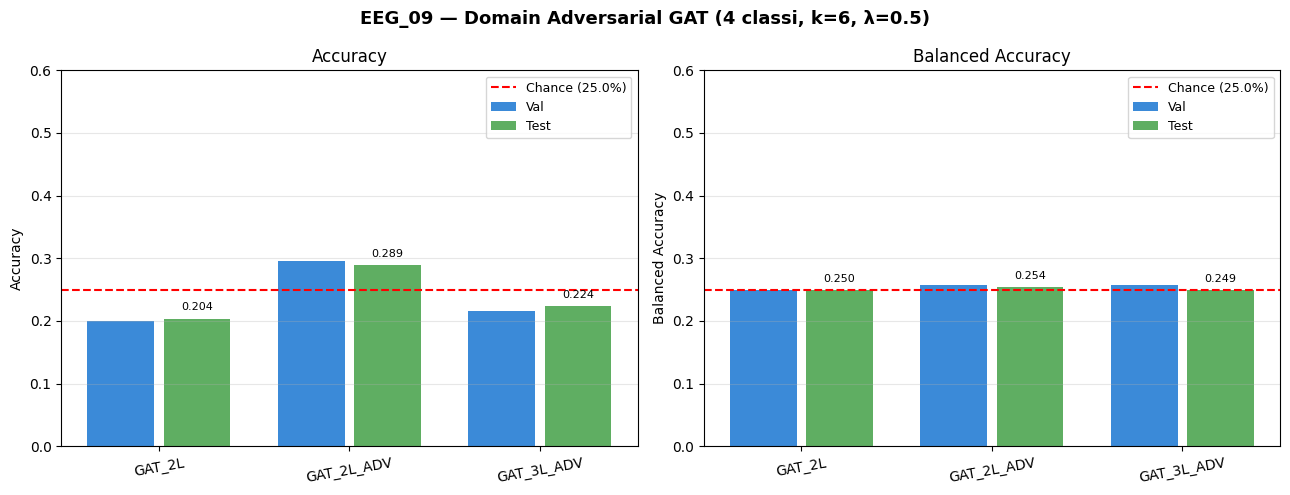

Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg09_gat_results_4cls.png


In [14]:
# ============================================================
# BAR CHART — confronto modelli GAT
# ============================================================

df_gat = pd.read_csv(RESULTS_CSV) if RESULTS_CSV.exists() else pd.DataFrame(results_gat)
chance = 1.0 / N_CLASSES

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"EEG_09 — Domain Adversarial GAT ({N_CLASSES} classi, k={K_GRAPH}, λ={LAMBDA_ADV})",
             fontsize=13, fontweight="bold")

colors_val  = ["#1976D2", "#1976D2", "#1976D2"]
colors_test = ["#43A047", "#43A047", "#43A047"]
models_order = list(GAT_MODELS.keys())
x = np.arange(len(models_order))

df_plot = df_gat.set_index("model").reindex(models_order)

for ax_idx, metric in enumerate(["acc", "bacc"]):
    ax = axes[ax_idx]
    ax.bar(x - 0.2, df_plot[f"val_{metric}"],  0.35, label="Val",  color="#1976D2", alpha=0.85)
    ax.bar(x + 0.2, df_plot[f"test_{metric}"], 0.35, label="Test", color="#43A047", alpha=0.85)
    ax.axhline(chance, color="red", linestyle="--", linewidth=1.5,
               label=f"Chance ({chance:.1%})")
    ax.set_xticks(x); ax.set_xticklabels(models_order, rotation=10, fontsize=10)
    ax.set_ylabel("Balanced Accuracy" if metric == "bacc" else "Accuracy")
    ax.set_title("Balanced Accuracy" if metric == "bacc" else "Accuracy")
    ax.set_ylim(0, 0.6); ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    # Annotazioni
    for xi, name in zip(x, models_order):
        if name in df_plot.index and not pd.isna(df_plot.loc[name, f"test_{metric}"]):
            v = df_plot.loc[name, f"test_{metric}"]
            ax.text(xi + 0.2, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
fig_path = project_root / "figures" / f"eeg09_gat_results_{N_CLASSES}cls.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvato: {fig_path}")

Confusion matrix per: GAT_2L_ADV


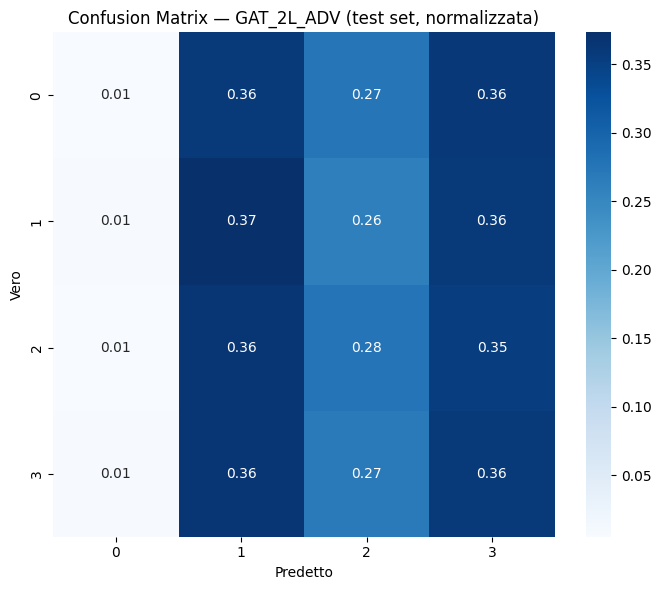

Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg09_confmat_GAT_2L_ADV.png


In [15]:
# ============================================================
# CONFUSION MATRIX — modello migliore su test set
# ============================================================

df_gat = pd.read_csv(RESULTS_CSV) if RESULTS_CSV.exists() else pd.DataFrame(results_gat)
best_model_name = df_gat.sort_values("test_bacc", ascending=False).iloc[0]["model"]
print(f"Confusion matrix per: {best_model_name}")

cfg = GAT_MODELS[best_model_name]
best_model = cfg["cls"]().to(device)
ckpt_path  = CKPT_BASE / f"{best_model_name}.pth"

if ckpt_path.exists():
    best_model.load_state_dict(torch.load(ckpt_path, map_location=device))
    best_model.eval()
    loader_te = PyGDataLoader(ds_test, batch_size=64, shuffle=False)
    ys_all, ps_all = [], []
    with torch.no_grad():
        for data in loader_te:
            data = data.to(device)
            if cfg["adversarial"]:
                logits, _ = best_model(data, alpha=0.0)
            else:
                logits = best_model(data)
            ps_all.extend(logits.argmax(1).cpu().tolist())
            ys_all.extend(data.y.cpu().tolist())

    cm = confusion_matrix(ys_all, ps_all, normalize="true")
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax,
                xticklabels=cluster_names, yticklabels=cluster_names)
    ax.set_xlabel("Predetto"); ax.set_ylabel("Vero")
    ax.set_title(f"Confusion Matrix — {best_model_name} (test set, normalizzata)")
    plt.tight_layout()
    fig_path = project_root / "figures" / f"eeg09_confmat_{best_model_name}.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Salvato: {fig_path}")
else:
    print(f"Checkpoint non trovato: {ckpt_path}")